In [2]:
import pandas as pd
import numpy as np
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
titan = pd.read_csv('data/Titanic-Dataset.csv')

In [4]:
titan

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
titan.info()
titan.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 66.2+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titan.select_dtypes(include = ['int64','float64']).corr()['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

In [7]:
titan['Family_Size'] = titan['SibSp'] + titan['Parch']
titan

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


In [8]:
titan.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Family_Size      0
dtype: int64

In [9]:
titan['Cabin'] = titan['Cabin'].fillna('Unassigned')
titan['Age'] = titan['Age'].fillna(titan['Age'].median())
titan['Embarked'] = titan['Embarked'].fillna(titan['Embarked'].mode()[0])

In [10]:
titan

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unassigned,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unassigned,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unassigned,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unassigned,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Unassigned,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


In [11]:
titan['Sex_Num'] = titan['Sex'].map({'male':1, 'female':2})
titan = pd.get_dummies(titan, columns = ['Embarked'], prefix = 'Src', dtype = int)
titan

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Family_Size,Sex_Num,Src_C,Src_Q,Src_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unassigned,1,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,2,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unassigned,0,2,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,2,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unassigned,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unassigned,0,1,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,0,2,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Unassigned,3,2,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,1,1,0,0


In [12]:
titan = titan[['PassengerId','Name','Age','Sex','Sex_Num','Family_Size','SibSp','Parch','Pclass','Cabin','Fare','Src_S','Src_C','Src_Q','Survived']]
titan

,PassengerId,Name,Age,Sex,Sex_Num,Family_Size,SibSp,Parch,Pclass,Cabin,Fare,Src_S,Src_C,Src_Q,Survived
0,1,"Braund, Mr. Owen Harris",22.0,male,1,1,1,0,3,Unassigned,7.2500,1,0,0,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,2,1,1,0,1,C85,71.2833,0,1,0,1
2,3,"Heikkinen, Miss. Laina",26.0,female,2,0,0,0,3,Unassigned,7.9250,1,0,0,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,2,1,1,0,1,C123,53.1000,1,0,0,1
4,5,"Allen, Mr. William Henry",35.0,male,1,0,0,0,3,Unassigned,8.0500,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",27.0,male,1,0,0,0,2,Unassigned,13.0000,1,0,0,0
887,888,"Graham, Miss. Margaret Edith",19.0,female,2,0,0,0,1,B42,30.0000,1,0,0,1
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,female,2,3,1,2,3,Unassigned,23.4500,1,0,0,0
889,890,"Behr, Mr. Karl Howell",26.0,male,1,0,0,0,1,C148,30.0000,0,1,0,1


In [16]:
titan_corr = titan.loc[:, ['Age','Sex_Num','Family_Size','Pclass','Fare','Survived']].corr()
titan_corr

,Age,Sex_Num,Family_Size,Pclass,Fare,Survived
Age,1.000000,-0.081163,-0.245619,-0.339898,0.096688,-0.064910
Sex_Num,-0.081163,1.000000,0.200988,-0.131900,0.182333,0.543351
Family_Size,-0.245619,0.200988,1.000000,0.065997,0.217138,0.016639
Pclass,-0.339898,-0.131900,0.065997,1.000000,-0.549500,-0.338481
Fare,0.096688,0.182333,0.217138,-0.549500,1.000000,0.257307
Survived,-0.064910,0.543351,0.016639,-0.338481,0.257307,1.000000


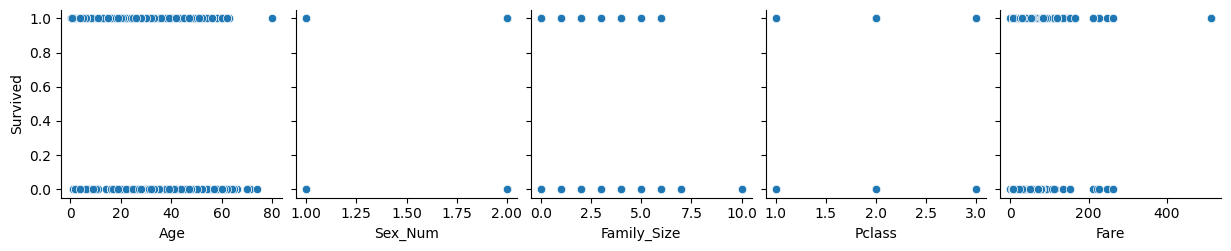

In [17]:
titan_num = titan.loc[:, ['Age','Sex_Num','Family_Size','Pclass','Fare','Survived']]
sns.pairplot(data = titan_num, x_vars = ['Age','Sex_Num','Family_Size','Pclass','Fare'], y_vars = ['Survived'])

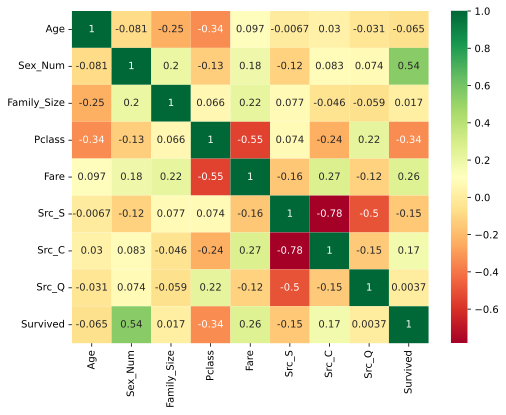

In [75]:
titan_corr1 = titan.loc[:, ['Age','Sex_Num','Family_Size','Pclass','Fare','Src_S','Src_C','Src_Q','Survived']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(titan_corr1,annot=True,cmap='RdYlGn')
plt.show()

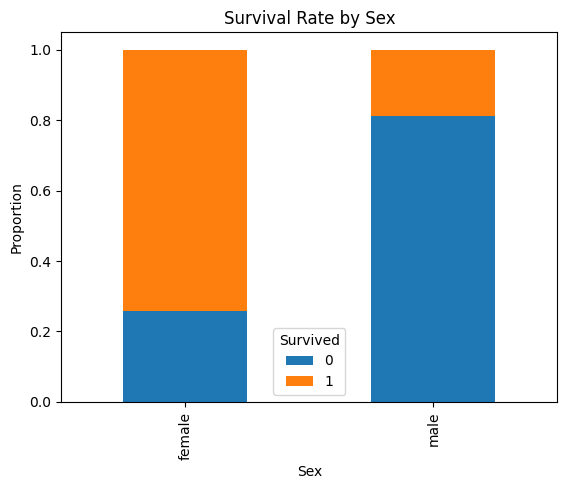

In [23]:
titan_sex_surv = pd.crosstab(titan['Sex'], titan['Survived'],normalize='index')
titan_sex_surv.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Survival Rate by Sex')
plt.show()

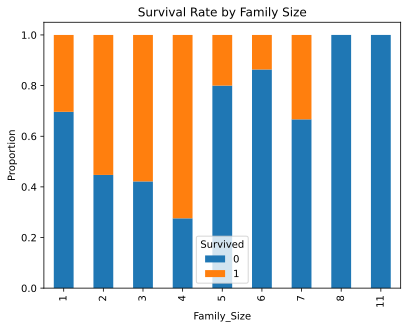

In [58]:
titan_fam_surv = pd.crosstab(titan['Family_Size']+1, titan['Survived'],normalize='index')
titan_fam_surv.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Survival Rate by Family Size')
plt.show()

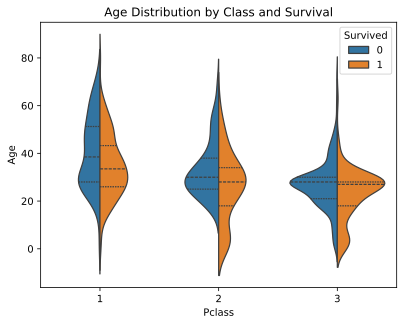

In [55]:
sns.violinplot(
    data=titan,
    x='Pclass',
    y='Age',
    hue='Survived',
    split=True,
    inner='quartile'
)
plt.title('Age Distribution by Class and Survival')
plt.ylabel('Age')
plt.show()

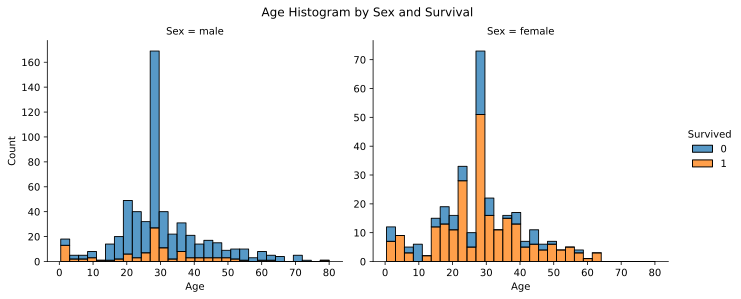

In [56]:
g = sns.displot(
    data=titan,
    x='Age',
    hue='Survived',
    col='Sex',
    kind='hist',
    bins=30,
    multiple='stack',
    height=4, aspect=1.2,
    facet_kws={'sharey': False}
)
g.set_axis_labels('Age', 'Count')
g.fig.suptitle('Age Histogram by Sex and Survival', y=1.03)
plt.show()


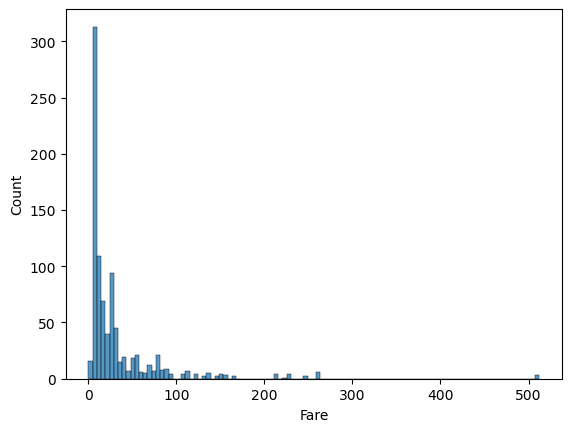

In [36]:
titan_faredist = sns.histplot(titan['Fare'])

Initial skew:  3.1878768213280524


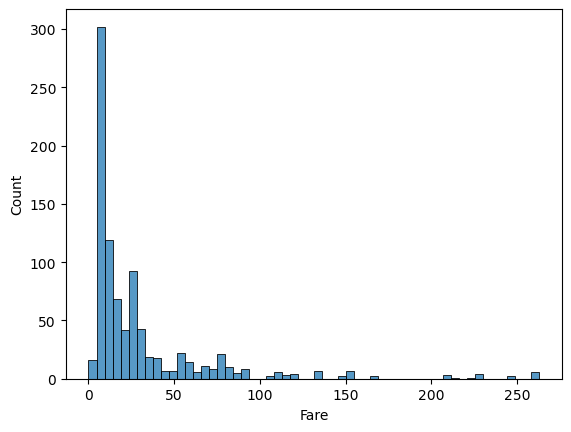

In [42]:
titan_fare_clean = titan[titan['Fare']<=300]
titan_faredist_1 = sns.histplot(titan_fare_clean['Fare'])
print("Initial skew: ", titan_fare_clean['Fare'].skew())

Final skew:  0.42170519706249754


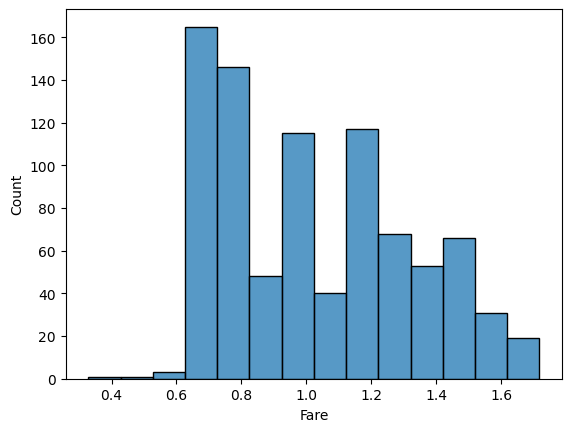

In [44]:
log_transform = np.log(np.log(titan_fare_clean['Fare']))
titan_faredist_2 = sns.histplot(log_transform)
print("Final skew: ", log_transform.skew())

In [45]:
%pylab inline

%config InlineBackend.figure_formats = ['svg']

from scipy import stats 
import math

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [64]:
condlist = [
        (titan['Sex']=='female') & ((titan['Age']<=16)|(titan['Age']>=50)),
        (titan['Sex']=='female') & ((titan['Age']>16)&(titan['Age']<50)),
        (titan['Sex']=='male')   & ((titan['Age']<=16)|(titan['Age']>=50)),
        (titan['Sex']=='male')   & ((titan['Age']>16)&(titan['Age']<50))
    ]
grouplist = ['FD','FW','MD','MW']
titan['Demographic'] = np.select(condlist, grouplist, default='Unknown')
summary = (titan.groupby('Demographic')['Survived'].agg(['sum','count']).rename(columns={'sum':'Survived','count':'Total'}))
summary['Rate'] = summary['Survived'] / summary['Total']
print(summary)

             Survived  Total      Rate
Demographic                           
FD                 53     71  0.746479
FW                180    243  0.740741
MD                 29    103  0.281553
MW                 80    474  0.168776


In [65]:
import scipy.stats as stats

contingency = pd.crosstab(titan['Demographic'], titan['Survived'])
chi2, p_global, dof, _ = stats.chi2_contingency(contingency)
print(f"Chi² = {chi2:.2f},   p-value = {p_global:.4g}")


Chi² = 267.61,   p-value = 1.016e-57


In [66]:
from statsmodels.stats.proportion import proportions_ztest

pairs = [('FD','FW'), ('FD','MD'), ('FD','MW')]
alpha  = 0.05 / len(pairs)

for g1, g2 in pairs:
    count  = summary.loc[[g1,g2],'Survived'].values
    nobs   = summary.loc[[g1,g2],'Total'].values
    stat, pval = proportions_ztest(count, nobs, alternative='larger')
    print(f"{g1} > {g2}?  z = {stat:5.2f}   p = {pval:.4f}")
    if pval < alpha:
        print ("Reject null hypothesis for: ", g1, " v/s ", g2)
    else:
        print ("Fail to reject null hypothesis for: ", g1, " v/s ", g2)


FD > FW?  z =  0.10   p = 0.4613
Fail to reject null hypothesis for:  FD  v/s  FW
FD > MD?  z =  6.04   p = 0.0000
Reject null hypothesis for:  FD  v/s  MD
FD > MW?  z = 10.57   p = 0.0000
Reject null hypothesis for:  FD  v/s  MW


In [54]:
titan

,PassengerId,Name,Age,Sex,Sex_Num,Family_Size,SibSp,Parch,Pclass,Cabin,Fare,Src_S,Src_C,Src_Q,Survived,Demographic
0,1,"Braund, Mr. Owen Harris",22.0,male,1,1,1,0,3,Unassigned,7.2500,1,0,0,0,MW
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,2,1,1,0,1,C85,71.2833,0,1,0,1,FW
2,3,"Heikkinen, Miss. Laina",26.0,female,2,0,0,0,3,Unassigned,7.9250,1,0,0,1,FW
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,2,1,1,0,1,C123,53.1000,1,0,0,1,FW
4,5,"Allen, Mr. William Henry",35.0,male,1,0,0,0,3,Unassigned,8.0500,1,0,0,0,MW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",27.0,male,1,0,0,0,2,Unassigned,13.0000,1,0,0,0,MW
887,888,"Graham, Miss. Margaret Edith",19.0,female,2,0,0,0,1,B42,30.0000,1,0,0,1,FW
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,female,2,3,1,2,3,Unassigned,23.4500,1,0,0,0,FW
889,890,"Behr, Mr. Karl Howell",26.0,male,1,0,0,0,1,C148,30.0000,0,1,0,1,MW
